# Matplotlib 终极复习手册

> 涵盖：架构 → 样式 → 文本 → 图例 → 刻度 → 柱状图(并列/堆叠) → 饼图 → 面积图 → 直方图 → 箱线图 → 散点气泡 → 折线图 → fill_between → 双Y轴 → errorbar → imshow热力 → 多子图(subplots/GridSpec) → 高级样式 → Economist风格 → 保存 → 速查表

## 0. 环境准备

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ============================================================
# rcParams 是什么？
# ============================================================
# rcParams 是一个全局"配置字典"（类似 dict），存着 Matplotlib 所有默认参数。
# "rc" 来自 Unix 传统 = "run commands" / "resource configuration"。
# 它控制字体、线宽、颜色、刻度、图例... 一切你能看到的样式细节。
# 好处：在代码开头统一配置一次，后面所有图表都自动应用，不用每个 plot() 重复设。
# 试试 print(plt.rcParams.keys())  查看全部 200+ 个可配置项

#macOS/Linux 没有 "Microsoft YaHei"——这也是为什么更稳妥的做法是用 ['SimHei']（黑体）或 ['Noto Sans CJK SC']（思源黑体）等跨平台字体。

# 1) 设置中文字体：让中文标签正常显示，不变成方框 □□□
#    Matplotlib 默认字体 DejaVu Sans 只有西文字形，遇到中文就显示方块。
#    这里把 'Microsoft YaHei'（微软雅黑）插到字体回退列表最前面，
#    中文由微软雅黑接管，英文仍 fallback 到默认西文字体。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

# 2) 关闭 Unicode 负号：
#    默认负号是 Unicode 专用字符 "−" (U+2212)，但中文字体通常没有这个字形，
#    导致负号显示成方框或直接消失。设为 False 后改用普通 ASCII 连字符 "-"。
plt.rcParams['axes.unicode_minus'] = False

# 查看 Matplotlib 内置的所有样式表名称（就是一键换肤的主题包列表）
print(plt.style.available)

print(f'Matplotlib {matplotlib.__version__}')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Matplotlib 3.10.8


---
## 1. Figure & Axes 架构

**Figure = 顶层容器(画布)，Axes = 实际图表(子图)**。一个 Figure 可包含多个 Axes。

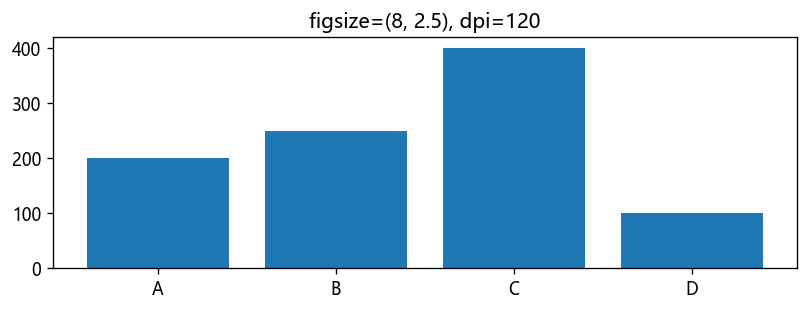

In [7]:
# plt.figure() 创建一个"画布"（Figure 对象）
# figsize=(宽, 高) 单位是英寸，dpi 是像素密度（dots per inch）
# 实际像素 = 8英寸 × 120dpi = 960px 宽
# 注意：所有 plt.xxx() 画图函数必须在 figure 创建之后调用！
plt.figure(figsize=(8, 2.5), dpi=120)
plt.bar(['A', 'B', 'C', 'D'], [200, 250, 400, 100])
plt.title('figsize=(8, 2.5), dpi=120')
plt.show()

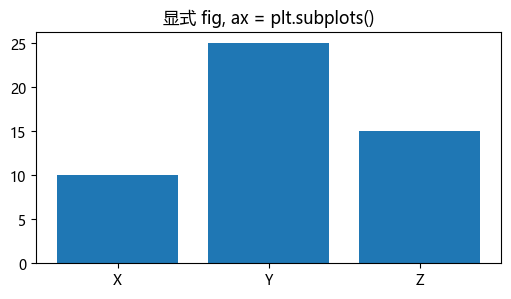

In [8]:
# subplots() 同时创建 Figure（画布）和 Axes（坐标系/图表区），返回 (fig, ax) 元组
# 这是推荐的"面向对象"写法，比直接用 plt.xxx() 更精确 —— 你知道在哪个 ax 上操作
# 后续所有绘图操作都用 ax.方法名()，而不是 plt.方法名()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['X', 'Y', 'Z'], [10, 25, 15])
ax.set_title('显式 fig, ax = plt.subplots()')
plt.show()

---
## 2. 颜色、点形、线形

### 2.1 颜色 — 5种写法

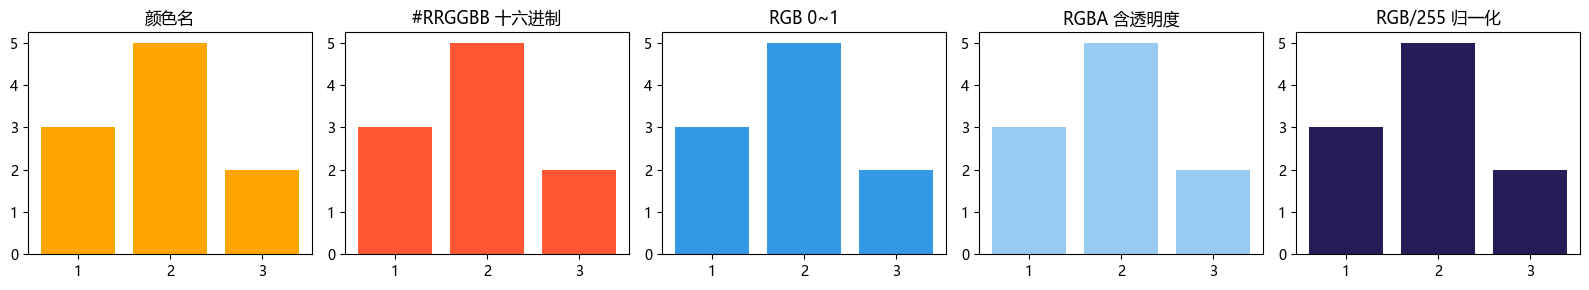

In [9]:
# 颜色的 5 种写法，记住前三种就够了：
# 1. 颜色名字 'orange' — 最直观，但只有 140 种命名颜色
# 2. 十六进制 '#FF5733' — 前端/设计常用，RRGGBB 每两位 00~FF
# 3. RGB 元组 (0.2, 0.6, 0.9) — 每个值范围 0~1（不是 0~255！）
# 4. RGBA 元组 (r, g, b, a) — 最后一位 a 是透明度alpha，0=全透明 1=不透明
# 5. RGB/255 — 就是把 0~255 值除以 255 转换为 0~1，方便取色
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
titles = ['颜色名', '#RRGGBB 十六进制', 'RGB 0~1', 'RGBA 含透明度', 'RGB/255 归一化']
colors = ['orange', '#FF5733', (0.2, 0.6, 0.9), (0.2, 0.6, 0.9, 0.5), (38/255, 28/255, 87/255)]
# zip() 把三个列表"拉链式"对齐打包 → 每次循环同时拿到 (子图, 标题, 颜色)
# 等价于: for i in range(len(axes)): ax=axes[i]; title=titles[i]; c=colors[i]
for ax, title, c in zip(axes, titles, colors):
    ax.bar([1, 2, 3], [3, 5, 2], color=c)
    ax.set_title(title)
plt.tight_layout()  # 自动调整子图间距，避免标签重叠
plt.show()

### 2.2 点形 Marker（常用）

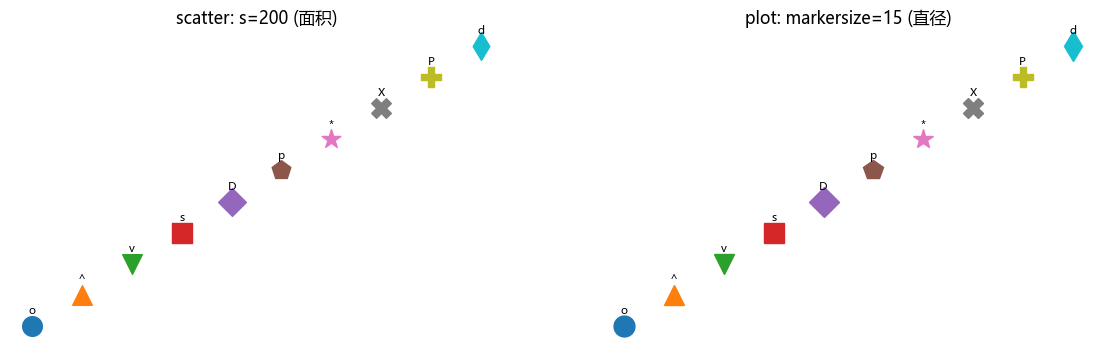

cell N


In [10]:
# ============================================================
# enumerate() 同时返回 (索引号, 元素值), 一行搞定 i 和 m
# 等价于: for i in range(len(markers)): m = markers[i]
# ============================================================
# scatter vs plot 的区别:
#   - scatter: 天生画散点图, s= 控制点的【面积】(平方点)
#   - plot:    天生画折线图, markersize= 控制点的【直径】(点)
#   s=200 的面积 ≈ markersize=16 的直径, 两者视觉效果接近但单位不同
# ============================================================
# text() 文字位置参数:
#   i+0.4 → 比点的 Y 坐标高 0.4 个单位, 紧贴在点上方 (数据坐标)
#   ha (horizontal alignment) 水平对齐: 'left'/'center'/'right'
#   va (vertical alignment)   垂直对齐: 'top'/'center'/'bottom'
# ============================================================
markers = ['o', '^', 'v', 's', 'D', 'p', '*', 'X', 'P', 'd']
x = np.arange(len(markers))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 左图: scatter 画点, s= 单位是面积(平方点)
for i, m in enumerate(markers):          # i=序号(0,1,2...)用作坐标, m=标记字符('o','^'...)
    axes[0].scatter(i, i, marker=m, s=200)  # s=200 面积, 约等于直径 16 点的圆
    axes[0].text(i, i+0.4, m, ha='center', fontsize=8)
axes[0].set_title('scatter: s=200 (面积)')
axes[0].axis('off')  # 关闭坐标轴, 突出点形展示

# 右图: plot 画点, markersize= 单位是直径(点), linestyle='None' 不连线
for i, m in enumerate(markers):
    axes[1].plot(i, i, marker=m, markersize=15, linestyle='None')
    axes[1].text(i, i+0.4, m, ha='center', fontsize=8)
axes[1].set_title('plot: markersize=15 (直径)')
axes[1].axis('off')

plt.show()
print("cell N")

### 2.3 线形 & 格式化字符串

In [ ]:
# 格式字符串 = [颜色字符][点形字符][线形字符]，三个部分顺序不限，但通常按这个写
# 颜色: 'r'红 'g'绿 'b'蓝 'c'青 'm'品红 'y'黄 'k'黑 'w'白
# 点形: 'o'圆 '^'上三角 'v'下三角 's'方块 'D'菱形 '*'星 'X'叉 '+'加号
# 线形: '-'实线 '--'虚线 ':'点线 '-.'点划线
# 举例: 'r*-.' = 红色 + 星号标记 + 点划线
x = [1, 2, 3, 4, 5]
fmt_strings = ['r*-.', 'g^--', 'bs-', 'co:', 'mD-', 'k+--']

# np.random.seed() 固定随机种子 — 每次运行 Y 值都一样, 方便对比
np.random.seed(42)
plt.figure(figsize=(10, 5))
for fmt in fmt_strings:
    # fmt 第一次出现: 第三个参数, 控制这条线的 [颜色][点形][线形] 三要素
    # fmt 第二次出现: label=fmt, 把格式字符串本身作为图例标签, 方便对照
    plt.plot(x, np.array(x) * np.random.randint(1, 10), fmt,
             linewidth=2, markersize=10, label=fmt)
plt.legend(fontsize=11, ncol=2)
plt.title('[颜色][点形][线形] 格式字符串', fontsize=14)
plt.show()

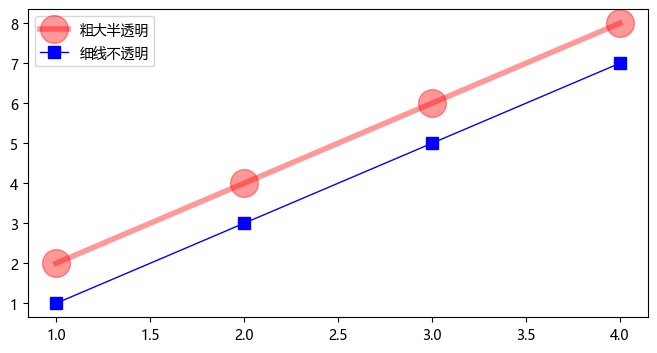

In [26]:
# linewidth / markersize / alpha
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3, 4], [2, 4, 6, 8], 'r-o', linewidth=4, markersize=20, alpha=0.4, label='粗大半透明')
plt.plot([1, 2, 3, 4], [1, 3, 5, 7], 'b-s', linewidth=1, markersize=8,  alpha=1.0, label='细线不透明')
plt.legend()
plt.show()

---
## 3. 文本与注释

| 函数 | 坐标系 |
|------|--------|
| `plt.title()` / `ax.set_title()` | 数据坐标 |
| `plt.xlabel()` / `plt.ylabel()` | 数据坐标 |
| `plt.text(x, y, s)` | 数据坐标 |
| `plt.annotate(s, xy, xytext, arrowprops)` | 数据坐标 |
| `ax.text(x, y, s, transform=ax.transAxes)` | Axes (0~1) 比例坐标 |
| `fig.text(x, y, s)` | Figure (0~1)比例坐标 |
| `fig.suptitle()` | Figure (0~1) 比例坐标|

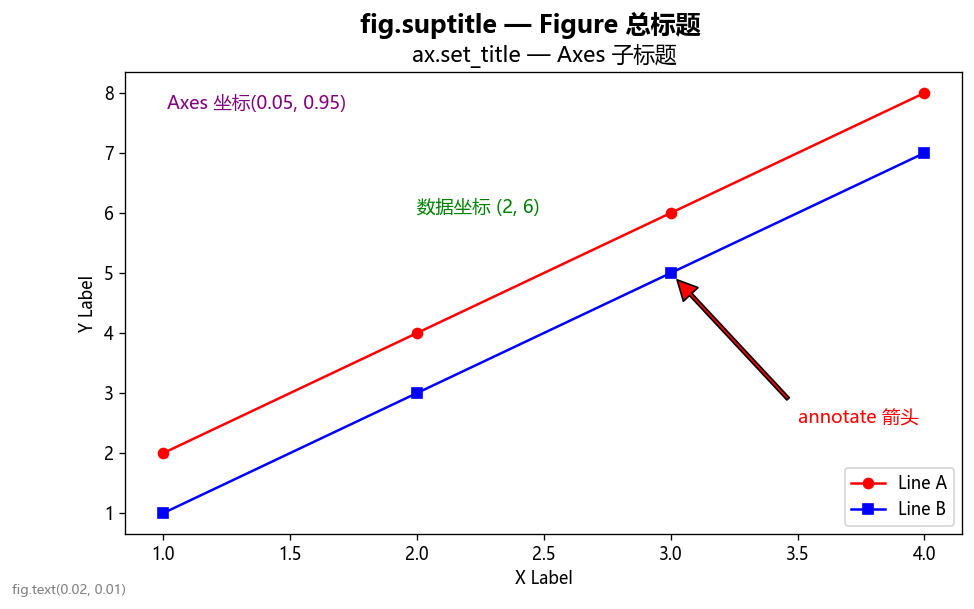

In [5]:
# 文本与注释：Matplotlib 有三种坐标系，这是最容易混淆的地方！
#
# 1. 数据坐标（默认）：(x, y) 就是数据轴上对应的位置
#    ax.text(2, 6, ...) → x=2, y=6 在数据轴上
#
# 2. Axes 比例坐标（transform=ax.transAxes）：(0, 0)=左下角, (1, 1)=右上角
#    不管数据范围怎么变，(0.5, 0.95) 永远是 Axes 区域的顶部居中
#    适合放标题、水印、图例等需要固定相对位置的元素
#
# 3. Figure 比例坐标（fig.text）：(0, 0)=画布左下, (1, 1)=画布右上
#    跨所有子图，通常用于页脚注释

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)

ax.plot([1, 2, 3, 4], [2, 4, 6, 8], 'r-o', label='Line A')
ax.plot([1, 2, 3, 4], [1, 3, 5, 7], 'b-s', label='Line B')

# suptitle = Figure 级别的总标题（跨所有子图），与每个 ax 的 set_title 不同
fig.suptitle('fig.suptitle — Figure 总标题', fontsize=15, fontweight='bold', y=0.98)
ax.set_title('ax.set_title — Axes 子标题', fontsize=13)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')

# text 默认使用数据坐标 —— (2, 6) 就是数据中 x=2, y=6 的位置
ax.text(2, 6, '数据坐标 (2, 6)', fontsize=11, color='green')

# text + transAxes —— (0.05, 0.95) 意思是"Axes 区域左侧 5%、顶部 95% 的位置"
# 这个位置不管数据怎么变，始终在左上角附近
ax.text(0.05, 0.95, 'Axes 坐标(0.05, 0.95)', transform=ax.transAxes,
        fontsize=11, color='purple', va='top')

# annotate：画一个箭头，从 xytext 指向 xy
# xy=(3, 5) 是箭头尖端位置，xytext=(3.5, 2.5) 是文字位置
# shrink=0.05 让箭头尖端离目标点缩一点距离，不要完全戳到点上
ax.annotate('annotate 箭头', xy=(3, 5), xytext=(3.5, 2.5),
            arrowprops=dict(facecolor='red', shrink=0.05, width=2),
            fontsize=11, color='red')

# fig.text 用 Figure 坐标系，(0.02, 0.01) = 画布左下角偏一点
fig.text(0.02, 0.01, 'fig.text(0.02, 0.01)', fontsize=8, color='gray')

ax.legend()
plt.show()

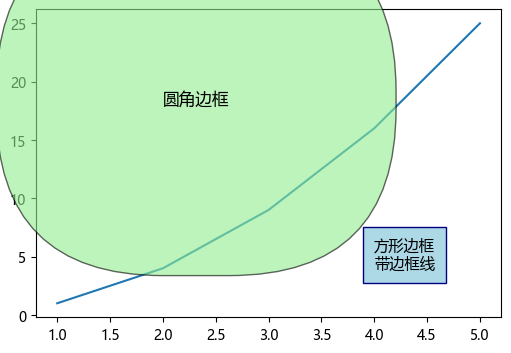

In [6]:
# 文本框
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4, 5], [1, 4, 9, 16, 25])
plt.text(2, 18, '圆角边框', fontsize=12,
         bbox={'facecolor': 'lightgreen', 'alpha': 0.6, 'pad': 10, 'boxstyle': 'round'})
plt.text(4, 4, '方形边框\n带边框线', fontsize=11,
         bbox={'facecolor': 'lightblue', 'edgecolor': 'navy', 'pad': 8})
plt.show()

### 实战：柱状图加数值标注（data= 传参法）

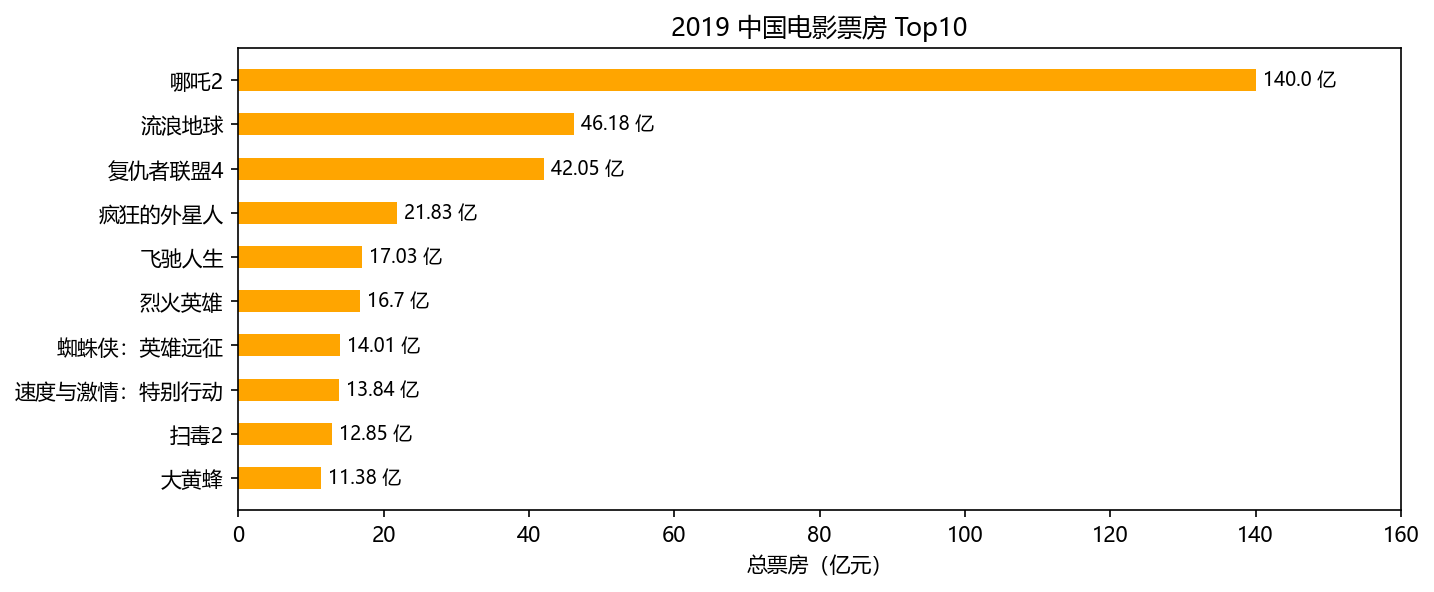

In [22]:
df = pd.read_excel(r'd:\VScode\jupyter_program\数据可视化\Matplotlib入门\电影票房数据.xlsx')

plt.figure(figsize=(10, 4), dpi=150)

# data= 参数：直接把 DataFrame 列名以字符串形式传给 x/y，比 df['col'] 更简洁
# barh = 水平柱状图（horizontal bar），y=类别列，width=数值列
plt.barh('电影名称', '总票房（亿元）', data=df, color='orange', height=0.5)
plt.xlabel('总票房（亿元）')
plt.title('2019 中国电影票房 Top10')

# gca() = "get current axes"，获取当前活跃的 Axes 对象以便精细操作
# invert_yaxis() 翻转Y轴，让票房最高的排在顶部（默认是从下往上排）
plt.gca().invert_yaxis()

# ============================================================
# 在每根柱子右边标注具体数值
# ============================================================
# 为什么这里不用 data= 参数？
#   data= 是 plt.barh / plt.plot 等"绘图函数"的专属参数，
#   zip() 是 Python 内置函数，plt.text() 是文本注释函数，都不支持 data=。
#   所以这里只能用 df['列名'] 直接取列。
# ============================================================
# enumerate(zip(A, B)) 拆解：
#   (1) zip(df['电影名称'], df['总票房（亿元）'])
#       → 把两列"拉链式"配对，生成迭代器:
#         ('哪吒之魔童降世', 50.35), ('流浪地球', 46.86), ...
#   (2) enumerate(...)
#       → 给每一对加上序号: (0, ('哪吒...', 50.35)), (1, ('流浪...', 46.86)), ...
#   (3) for i, (name, val) in ...:
#       → i=序号(0,1,2...) 用作 barh 的 Y 轴坐标, 控制每行标注的垂直位置
#       → name=电影名(本例未使用), val=票房值
#   (4) plt.text(x=val+1, y=i, ...)
#       → 在水平位置 val+1(紧贴柱子右侧)、垂直位置 i(第几行) 处写字
#       → va='center' 让文字在每行柱子的垂直居中位置
# ============================================================
for i, (name, val) in enumerate(zip(df['电影名称'], df['总票房（亿元）'])):
    plt.text(val+1, i, f'{val} 亿', va='center', fontsize=9)

# ============================================================
# plt.xlim(left, right) 设置 X 轴显示范围
#   left=0:  从 0 开始
#   right=最高票房+20:  右侧多留 20 个单位空白
#   注意：标注文字在 val+1 处，xlim留白需要达到让标注的文字显示在表内的效果
#   这里 +20 纯粹是为了右侧留白美观，和标注是否被裁无关。
#   实际值越大，图表右侧空白越多，视觉上不那么拥挤。
#   类似函数: plt.ylim(bottom, top) 控制 Y 轴范围。
# ============================================================
plt.xlim(0, df['总票房（亿元）'].max()+20)
plt.show()

---
## 4. 图例 Legend

**`loc=`**：`'best'`(0) / `'upper right'`(1) / `'upper left'`(2) / `'lower left'`(3) / `'lower right'`(4) / `'center'` / 或 `(x, y)` 比例坐标

**`ncol=`**：图例列数 | **`frameon=`**：是否显示边框

In [ ]:
plt.figure(figsize=(8, 4))
for i in range(6):
    plt.plot([1, 2, 3], np.arange(1, 4) * (i+1), marker='o', label=f'Series {i+1}')

# 图例在左上角，无边框，分2列，带标题
plt.legend(loc='upper left', frameon=False, ncol=2, title='图例标题', fontsize=9)
plt.title('legend(ncol=2, frameon=False)')
plt.show()

In [ ]:
# bbox_to_anchor：把图例的"锚点"定位到指定位置
# loc='upper left' 意思是图例自身的左上角放在 bbox_to_anchor 位置
# bbox_to_anchor=(1, 1) 用的是 Axes 比例坐标，(1, 1) = Axes 右上角
# 效果：图例的左上角紧贴 Axes 右上角 → 图例整体在图表外面右侧
plt.figure(figsize=(8, 4))
for i in range(3):
    plt.plot([1, 2, 3], np.arange(1, 4) * (i+1), marker='o', label=f'Line {i+1}')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='外部图例')
plt.tight_layout()  # 必须调 tight_layout，否则图例可能被裁掉
plt.show()

---
## 5. 刻度与网格

In [ ]:
# 主刻度 vs 副刻度：主刻度有标签（数字/文字），副刻度只有短刻线没有标签
# 副刻度通过 minor=True 开启，一般用于更细粒度的参考线
x = np.linspace(0, 10, 50)
plt.figure(figsize=(9, 5))
plt.plot(x, np.sin(x), 'b-', linewidth=2)

# 主刻度：设置刻度位置 + 标签
plt.xticks(np.arange(0, 11, 1), rotation=45)  # X轴 0~10 每 1 格，标签旋转 45°
plt.yticks(np.arange(-1, 1.5, 0.5))           # Y轴 -1~1 每 0.5 格

# 副刻度（minor=True）：只有小短线，没标签，通常比主刻度更密
plt.yticks(np.arange(-0.75, 1.25, 0.5), minor=True)

# which='major' 给主刻度画网格，which='minor' 给副刻度画网格
plt.grid(axis='y', which='major', linestyle='-', alpha=0.5)
plt.grid(axis='y', which='minor', linestyle=':', alpha=0.2)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.title('主刻度 + 副刻度 + 网格')
plt.show()

### `plt.gca()` — 获取当前 Axes 精细控制

In [ ]:
# plt.gca() = "get current axes" 获取当前活跃的 Axes 对象
# 适合"先画后改"：用 plt.xxx() 快速画图，再拿 gca() 回来精调细节
# spines = 坐标轴的四根边框线（top/bottom/left/right），可以单独控制显示/隐藏
plt.figure(figsize=(7, 4))
plt.bar([0, 1, 2], [10, 15, 20])

ax = plt.gca()  # 拿到当前 Axes，接下来精细控制
ax.set_xticklabels(['项目A', '项目B', '项目C'], rotation=30)
ax.set_ylabel('数值')
# 隐藏上方和右方的边框线（常见于商业图表风格，让图表看起来更干净）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('plt.gca() 精细控制')
plt.show()

---
## 6. Pandas 与 Matplotlib 结合

两种写法：`plt.bar(df['col1'], df['col2'])` 或 `plt.bar('col1', 'col2', data=df)`

In [ ]:
df = pd.read_excel(r'd:\VScode\jupyter_program\数据可视化\Matplotlib入门\电影票房数据.xlsx')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

axes[0].barh(df['电影名称'], df['总票房（亿元）'], color='orange', height=0.5)
axes[0].set_title('写法一: df[col]')
axes[0].invert_yaxis()

axes[1].barh('电影名称', '总票房（亿元）', data=df, color='steelblue', height=0.5)
axes[1].set_title('写法二: data=df')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 保存图片

In [ ]:
# plt.savefig('output.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
# bbox_inches='tight' — 裁掉多余白边
# facecolor='white'   — 背景色
# transparent=True    — 透明背景

---
## 7. 柱状图

### 7.1 并列柱状图 — N 组通用公式

核心：`np.arange` 生成位置 → 每组 ± offset 错开 → `width` 控制柱宽

In [ ]:
# 并列柱状图的核心思路：
# 1. np.arange(N) 生成 N 个整数位置 [0, 1, 2, ...] 作为每组柱子的中心
# 2. 每组柱子 ±width/2 错开：一组向左偏半个柱宽，一组向右偏半个柱宽
# 3. width 控制每根柱子的宽度
categories = ['项目A', '项目B', '项目C']
male = [10, 15, 20]
female = [12, 14, 25]

width = 0.35                               # 每根柱子宽度
x = np.arange(len(categories))             # [0, 1, 2] — 三组的中心位置

plt.figure(figsize=(7, 4), dpi=120)
plt.bar(x - width/2, male,   width=width, label='男生', color='steelblue')   # 左偏半宽
plt.bar(x + width/2, female, width=width, label='女生', color='lightcoral')  # 右偏半宽
plt.xticks(x, labels=categories)           # 把 [0,1,2] 的标签替换为类别名
plt.ylabel('人数')
plt.title('并列柱状图')
plt.legend()
plt.show()

In [ ]:
# === N 组通用函数 ===
# 原理：用 np.linspace 在一组柱子范围内均匀分配 offset
# 比如 3 组柱子：偏移量分别是 -width/3, 0, +width/3
def grouped_bar(cats, groups, total_width=0.8):
    """groups: {'组名': [值...], ...}"""
    n = len(groups)                                # 一共几组
    x = np.arange(len(cats))                       # 中心位置 [0, 1, 2, ...]
    w = total_width / n                            # 每组柱子的宽度 = 总宽 / 组数
    # 计算每组的偏移量，从 -总宽/2+w/2 到 +总宽/2-w/2，均匀分布
    offsets = np.linspace(-total_width/2 + w/2, total_width/2 - w/2, n)
    for (label, vals), off in zip(groups.items(), offsets):
        plt.bar(x + off, vals, width=w, label=label)
    plt.xticks(x, labels=cats)
    plt.legend()

plt.figure(figsize=(10, 4))
grouped_bar(['Q1', 'Q2', 'Q3', 'Q4'], {
    '产品A': [100, 120, 140, 160],
    '产品B': [80, 90, 110, 130],
    '产品C': [60, 75, 85, 100]
})
plt.title('N 组并列柱状图通用公式')
plt.show()

### 7.2 堆叠柱状图 — `bottom=` (竖直) / `left=` (水平)

In [ ]:
# 堆叠柱状图的核心：bottom（竖直）/ left（水平）
# 第二组柱子的 bottom = 第一组的值，第三组的 bottom = 前两组之和
# 效果就是柱子"叠"在上面，而不是"并排"
cats = ['A', 'B', 'C', 'D']
b1, b2, b3 = [10, 15, 18, 11], [5, 6, 7, 8], [4, 5, 6, 7]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 竖直堆叠：bottom 参数控制柱子从多高的位置开始画
axes[0].bar(cats, b1, label='Type I')
axes[0].bar(cats, b2, bottom=b1, label='Type II')                # 叠在 b1 上面
axes[0].bar(cats, b3, bottom=np.add(b1, b2), label='Type III')    # 叠在 b1+b2 上面
axes[0].set_title('bottom= 竖直堆叠')
axes[0].legend()

# 水平堆叠：left 参数控制柱子从多左的位置开始画（和 bottom 概念一样，只是方向不同）
axes[1].barh(cats, b1, label='Type I')
axes[1].barh(cats, b2, left=b1, label='Type II')
axes[1].barh(cats, b3, left=np.add(b1, b2), label='Type III')
axes[1].set_title('left= 水平堆叠')
axes[1].legend()

plt.tight_layout()
plt.show()

### 实战：餐厅吸烟/非吸烟顾客每日消费堆叠（含自定义排序 + merge 对齐）

In [ ]:
bills = pd.read_excel(r'd:\VScode\jupyter_program\数据可视化\柱状图\bills.xlsx')

agg = bills.groupby(['day', 'smoker']).agg({'total_bill': 'sum'}).reset_index()
smoker = agg[agg['smoker'] == 'Yes'][['day', 'total_bill']]
nonsmoker = agg[agg['smoker'] == 'No'][['day', 'total_bill']]
merged = smoker.merge(nonsmoker, on='day', suffixes=('_smoker', '_nonsmoker'))

# 自定义排序
order = ['Thur', 'Fri', 'Sat', 'Sun']
merged['sort_key'] = merged['day'].apply(lambda x: order.index(x))
merged = merged.sort_values('sort_key')

plt.figure(figsize=(9, 5), dpi=130)
plt.bar(merged['day'], merged['total_bill_smoker'], label='吸烟')
plt.bar(merged['day'], merged['total_bill_nonsmoker'],
        bottom=merged['total_bill_smoker'], label='非吸烟')
plt.title('餐厅每日消费 — 吸烟 vs 非吸烟')
plt.ylabel('总消费额')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

---
## 8. 饼图

`explode` 突出 | `autopct` 百分比格式 | `startangle` 起始角度 | `pctdistance` 文字距离圆心

In [ ]:
df = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\饼图与堆叠面积图\water_usage.csv')

plt.figure(figsize=(8, 8), dpi=130)

# pie() 返回三个值：wedges(扇形对象), texts(标签文字), autotexts(百分比文字)
wedges, texts, autotexts = plt.pie(
    df['Percentage'],            # 每个扇形的数值，会自动归一化为百分比
    labels=df['Usage'],          # 每个扇形的标签
    explode=[0, 0, 0.1, 0, 0, 0], # 突出第3个扇形（0.1 = 突出 10% 半径距离）
    autopct='%.1f%%',            # 百分比格式：保留 1 位小数 + % 号
    startangle=90,               # 起始角度 90°（从 12 点钟方向开始，默认从 3 点钟）
    pctdistance=0.6,             # 百分比文字离圆心的距离（0~1，1=边缘）
    shadow=True,                 # 阴影效果
    # plt.cm.Pastel1 是一个柔和配色方案的 colormap
    colors=plt.cm.Pastel1(np.linspace(0, 1, len(df))))

# 修改自动生成的百分比文字样式
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
plt.title('家庭用水分布', fontsize=15, fontweight='bold')
plt.show()

---
## 9. 堆叠面积图

In [ ]:
df = pd.read_excel(r'd:\VScode\jupyter_program\数据可视化\饼图与堆叠面积图\汽车.xlsx')

plt.figure(figsize=(8, 5), dpi=120)
plt.stackplot(df['Year'], df['XU7'], df['蔚去'], df['大鹏'],
              labels=['XU7', '蔚去', '大鹏'],
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.85)
plt.xlabel('年份'); plt.ylabel('销量（千辆）')
plt.title('汽车品牌年度销量')
plt.xticks([2021, 2022, 2023, 2024])
plt.legend(loc='upper left')
plt.show()

---
## 10. 直方图

`bins` 柱数 | `density=True` 概率密度 | `alpha` 透明度 | `edgecolor` 柱边缘颜色

In [ ]:
df = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\直方图与散点图\age_distribution.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('bins=20 (频数)')

axes[1].hist(df['age'], bins=15, density=True, color='orange', alpha=0.7, edgecolor='white')
axes[1].axvline(x=35, color='red', linestyle='--', linewidth=2, label='x=35')
axes[1].axhline(y=0.04, color='green', linestyle=':', linewidth=2, label='y=0.04')
axes[1].set_title('density=True + 参考线')
axes[1].legend()

axes[2].hist(np.random.normal(50, 10, 1000), bins=30, alpha=0.5, label='组A', color='red')
axes[2].hist(np.random.normal(60, 8, 1000), bins=30, alpha=0.5, label='组B', color='blue')
axes[2].set_title('两组叠加')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 11. 箱线图

箱体=Q1~Q3 | 中间线=中位数 | 须线=1.5×IQR | 点=离群值

In [ ]:
df = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\直方图与散点图\basketball.csv', index_col=0)
positions = ['Guard', 'Center', 'Forward']
data = [df[df['Position'] == p]['TotalPoints'] for p in positions]

plt.figure(figsize=(9, 5), dpi=130)
bp = plt.boxplot(data, labels=positions, patch_artist=True, widths=0.4,
                  showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=7))
for patch, c in zip(bp['boxes'], ['#FF9999', '#66B2FF', '#99FF99']):
    patch.set_facecolor(c)
plt.ylabel('得分'); plt.title('不同位置球员得分分布')
plt.grid(axis='y', alpha=0.3)
plt.show()

---
## 12. 散点图 & 气泡图

气泡图 = 散点 + `s=` 控制大小 + `alpha=` 透明度

In [ ]:
df = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\直方图与散点图\basketball.csv', index_col=0)
agg = df.groupby(['PlayerName', 'Position']).agg({'TotalPoints': 'mean', 'Rebounds': 'mean'}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

for pos, c in [('Guard', 'red'), ('Center', 'blue'), ('Forward', 'green')]:
    s = agg[agg['Position'] == pos]
    axes[0].scatter(s['Rebounds'], s['TotalPoints'], label=pos, color=c, alpha=0.6, s=80)
axes[0].set_xlabel('平均篮板'); axes[0].set_ylabel('平均得分')
axes[0].set_title('散点图'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 气泡图
df2 = pd.read_excel(r'd:\VScode\jupyter_program\数据可视化\直方图与散点图\市场定位.xlsx')
axes[1].scatter(df2['感知价格'], df2['品牌形象'], s=df2['顾客数量']/5, alpha=0.6,
                color='steelblue', edgecolor='black')
for _, row in df2.iterrows():
    axes[1].text(row['感知价格'] + 0.15, row['品牌形象'], row['品牌'], fontsize=9)
axes[1].set_xlabel('感知价格'); axes[1].set_ylabel('品牌形象')
axes[1].set_title('气泡图 (s= 控制大小)')

# 自定义气泡图例
for size, lbl in [(1000/5, '1,000'), (3000/5, '3,000'), (5000/5, '5,000')]:
    axes[1].scatter([], [], s=size, alpha=0.6, color='steelblue', edgecolor='black', label=lbl)
axes[1].legend(title='顾客数量', loc='lower right')

plt.tight_layout()
plt.show()

---
## 13. 折线图 & 股票实战

In [ ]:
google = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\GOOGL_data.csv')
fb = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\FB_data.csv')
aapl = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\AAPL_data.csv')
amzn = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\AMZN_data.csv')
msft = pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\MSFT_data.csv')

plt.figure(figsize=(16, 6), dpi=200)
for df, name in [(google, 'Google'), (fb, 'Facebook'), (aapl, 'Apple'), (amzn, 'Amazon'), (msft, 'Microsoft')]:
    plt.plot('date', 'close', data=df, label=name, linewidth=1.5)
plt.xticks(np.arange(0, 1260, 60), rotation=45)
plt.yticks(np.arange(0, 1500, 100))
plt.title('五大科技股收盘价走势', fontsize=16)
plt.ylabel('收盘价 ($)'); plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 14. fill_between — 填充两条线之间的区域

常用于展示范围/不确定性/正负差异。

In [ ]:
# fill_between：填充一条线到另一条线（或到 0）之间的区域
# 常用于：展示置信区间、预测范围、正负差异、波动带
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.sin(x) + 0.5

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) fill_between(x, y) — 只给一个y，默认填充 y 到 0 之间的区域
axes[0].fill_between(x, y1, alpha=0.3, color='blue')
axes[0].plot(x, y1, 'b-', linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # 画 y=0 参考线
axes[0].set_title('fill_between(x, y) 默认填充到0')

# 2) fill_between(x, y1, y2) — 给两个y，填充两条线之间的区域
axes[1].plot(x, y1, 'b-', linewidth=2, label='sin(x)')
axes[1].plot(x, y2, 'r-', linewidth=2, label='sin(x)+0.5')
axes[1].fill_between(x, y1, y2, alpha=0.3, color='purple')
axes[1].set_title('fill_between(x, y1, y2) 两线间')
axes[1].legend()

# 3) where= 条件填充 — 只在满足条件的地方填充
axes[2].plot(x, y1, 'b-', linewidth=2)
axes[2].fill_between(x, y1, 0, where=(y1 > 0), alpha=0.3, color='green', label='y>0')
axes[2].fill_between(x, y1, 0, where=(y1 <= 0), alpha=0.3, color='red', label='y<=0')
axes[2].set_title('where= 条件填充')
axes[2].legend()

plt.tight_layout()
plt.show()

### 置信区间实战

In [ ]:
# 置信区间实战：用 fill_between 展示回归线的不确定度
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.normal(0, 3, 50)  # y = 2x+1 + 噪声

# np.polyfit(x, y, 1) 做一次多项式（线性）拟合，返回 [斜率, 截距]
# np.poly1d(z) 把系数转成可调用的多项式函数 p(x)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
y_fit = p(x)                    # 拟合线上的 y 值
se = np.std(y - y_fit)          # 标准误（残差的标准差）

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label='数据')
plt.plot(x, y_fit, 'r-', linewidth=2, label='拟合线')
# 1.96 × SE ≈ 95% 置信区间（正态分布假设下）
plt.fill_between(x, y_fit - 1.96*se, y_fit + 1.96*se,
                 alpha=0.2, color='red', label='95% 置信区间')
plt.legend()
plt.title('fill_between — 置信区间')
plt.show()

---
## 15. twinx / twiny — 双轴图

当两组数据量纲不同但共享 X 轴时使用。

In [ ]:
# twinx() = "twin x-axis"，创建一个共享 X 轴但拥有独立 Y 轴的新 Axes
# 本质：两个 Axes 重叠在一起，X 轴同步，Y 轴各自独立
# 常用于：两组数据量纲完全不同但共享时间轴（如销售额+增长率）
months = ['1月', '2月', '3月', '4月', '5月', '6月']
sales = [120, 135, 148, 162, 155, 180]
growth_rate = [8, 12.5, 9.6, 9.5, -4.3, 16.1]  # %

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

# 左轴（ax1）：柱状图 — 销售额
ax1.bar(months, sales, color='steelblue', alpha=0.7, label='销售额', width=0.5)
ax1.set_ylabel('销售额（万元）', color='steelblue')       # Y轴标签同色
ax1.tick_params(axis='y', labelcolor='steelblue')        # Y轴刻度数字同色

# 右轴（ax2）：折线图 — 增长率，通过 twinx() 创建，和 ax1 共享 X 轴
ax2 = ax1.twinx()
ax2.plot(months, growth_rate, 'r-o', linewidth=2, markersize=10, label='增长率')
ax2.set_ylabel('增长率（%）', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # y=0 基准线

# 两个 Axes 各自有图例句柄，需要手动合并到一个图例里
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('双轴图：销售额（柱） + 增长率（线）')
plt.show()

---
## 16. errorbar — 误差线

适用于实验数据、统计结果展示不确定度。

In [ ]:
groups = ['A', 'B', 'C', 'D']
means = [25, 32, 28, 35]
stds = [3, 5, 2, 4]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# errorbar — 点估计 + 误差线
axes[0].errorbar(groups, means, yerr=stds, fmt='o', capsize=5, capthick=2,
                 color='darkblue', markersize=12, linewidth=2, ecolor='red', elinewidth=2)
axes[0].set_title('errorbar — 点 + 误差线')
axes[0].set_ylabel('均值'); axes[0].grid(axis='y', alpha=0.3)

# bar + errorbar 组合
bars = axes[1].bar(groups, means, yerr=stds, capsize=5, color='steelblue',
                    edgecolor='black', alpha=0.8)
axes[1].set_title('bar + yerr 误差线')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 17. imshow + colorbar — 矩阵可视化

Matplotlib 自己的热力图方案（Seaborn heatmap 更推荐，但 imshow 是底层基础）。

In [ ]:
# imshow：把 2D 数组/矩阵显示为彩色格子（热力图的基础）
# cmap 是 colormap（颜色映射方案），'viridis' 是默认推荐色（色盲友好）
# aspect='auto' 让格子自动拉伸填满 Axes，而不是强制正方形
np.random.seed(42)
data = np.random.rand(8, 10)   # 8行 × 10列 的随机矩阵

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 基础用法：imshow + colorbar 颜色条
im = axes[0].imshow(data, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=axes[0], label='数值', shrink=0.8)  # shrink 缩 colorbar 高度
axes[0].set_title('imshow + colorbar')
axes[0].set_xticks(range(10))   # 10 列
axes[0].set_yticks(range(8))    # 8 行

# 进阶：每个格子里标注数值
im2 = axes[1].imshow(data, cmap='YlOrRd', aspect='auto')  # 黄-橙-红 colormap
cbar = plt.colorbar(im2, ax=axes[1], shrink=0.8)
cbar.set_label('值')
# 在每个格子中心标注对应的数值
for i in range(8):       # 行
    for j in range(10):  # 列
        axes[1].text(j, i, f'{data[i,j]:.2f}', ha='center', va='center', fontsize=7)
axes[1].set_title('imshow + 数值标注')

plt.tight_layout()
plt.show()

---
## 18. 多子图 — subplots() 均匀网格

In [ ]:
stocks = [
    ('Google', pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\GOOGL_data.csv')),
    ('Facebook', pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\FB_data.csv')),
    ('Apple', pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\AAPL_data.csv')),
    ('Amazon', pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\AMZN_data.csv')),
    ('Microsoft', pd.read_csv(r'd:\VScode\jupyter_program\数据可视化\多子图\MSFT_data.csv')),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=130)
fig.suptitle('五巨头收盘价 多子图', fontsize=18, fontweight='bold')

for i, (name, data) in enumerate(stocks):
    ax = axes.flat[i]
    ax.plot('date', 'close', data=data, linewidth=1.2)
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(np.arange(0, 1260, 200))
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('收盘价 ($)')
    ax.grid(alpha=0.3)

axes.flat[5].set_visible(False)  # 隐藏多余子图
plt.subplots_adjust(wspace=0.25, hspace=0.4)
plt.show()

In [ ]:
# plt.sca() — 切换当前 Axes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot([1, 2, 3], [1, 4, 9])
axes[0].set_title('axes[0] 索引')

plt.sca(axes[1])
plt.plot([1, 2, 3], [3, 2, 1], 'r-o')
plt.title('sca(axes[1])')

plt.sca(axes[2])
plt.bar(['A', 'B'], [10, 20])
plt.title('sca(axes[2])')

plt.tight_layout()
plt.show()

---
## 19. 多子图 — GridSpec 不均匀布局

In [ ]:
# GridSpec：把 Figure 切成网格，然后自由选择每个子图占几行几列
# subplots() 只能做均匀网格（每个子图一样大），GridSpec 能做不规则布局
# gs[a:b, c:d] 就是拿第 a 行到第 b-1 行、第 c 列到第 d-1 列的区域
# 比如 gs[0:2, 0:3] = 占前 2 行 + 前 3 列 = 一个大矩形

fig = plt.figure(figsize=(12, 8), dpi=120)
gs = matplotlib.gridspec.GridSpec(3, 4, figure=fig)  # 3行 × 4列 的网格

# 主图：占第 0~1 行（前2行），第 0~2 列（前3列）= 2×3 的大区域
ax1 = fig.add_subplot(gs[0:2, 0:3])
ax1.bar(['Q1', 'Q2', 'Q3', 'Q4'], [100, 120, 140, 160], color='steelblue')
ax1.set_title('主图: 2行x3列')
ax1.grid(axis='y', alpha=0.3)

# 右上角饼图：占第 0 行，第 3 列 = 1×1 小方格
ax2 = fig.add_subplot(gs[0, 3])
ax2.pie([30, 25, 20, 15, 10], autopct='%d%%', textprops={'fontsize': 8})
ax2.set_title('饼图')

# 右中折线图：占第 1 行，第 3 列
ax3 = fig.add_subplot(gs[1, 3])
ax3.plot([1, 2, 3, 4], [2, 4, 1, 5], 'r-o')
ax3.set_title('趋势')

# 底部直方图：占第 2 行，所有列（用 : 表示全部）= 1行 × 4列 横跨底部
ax4 = fig.add_subplot(gs[2, :])
ax4.hist(np.random.normal(100, 15, 500), bins=30, color='coral', edgecolor='white')
ax4.set_title('底部横跨: 1行x4列')

plt.tight_layout()
plt.show()

---
## 20. 高级样式 — spines / facecolor / axisbelow

In [ ]:
# 高级样式：精细控制 Figure/Axes 的背景色、边框线、网格层级
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

# patch = 一个矩形的背景区域，fig.patch 是画布背景，ax 是坐标轴背景
fig.patch.set_facecolor('#e8e8e8')  # 画布（整张图）背景设为浅灰
ax.set_facecolor('#f5f5f5')         # Axes（图表区）背景设为更浅的灰

ax.bar(['A', 'B', 'C', 'D'], [25, 35, 20, 40], color='steelblue', edgecolor='white')

# spines = 四根坐标轴边框线，可以分别隐藏/显示
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.yaxis.tick_right()  # 把 Y 轴刻度从左边移到右边（常见于某些商业图表排版）

# set_axisbelow(True) 确保网格线画在数据的"下方"（否则网格线会盖在柱子上方）
ax.grid(axis='y', color='white', linewidth=1.5)
ax.set_axisbelow(True)

ax.set_title('高级样式: 背景色 + spines + 网格', fontweight='bold')
plt.show()

---
## 21. 商业图表实战 — 仿经济学人(Economist)风格

综合运用：背景色 + transAxes 文本定位 + spines + 自定义图例位置

In [ ]:
# ============================================================
# 仿经济学人(Economist)风格：综合运用前面学的一切
# 特点：大标题（transAxes 定位在图表上方）+ 浅蓝灰背景 + 隐藏多余 spines + Y轴右移
# ============================================================
df = pd.read_excel(r'd:\VScode\jupyter_program\数据可视化\商务案例\business.xlsx')

# facecolor 直接设整个 Figure 的背景色（浅蓝灰），省去单独设 fig.patch
fig, ax = plt.subplots(figsize=(7, 7), dpi=200, facecolor='#D1DBE6')

# 并列柱状图（前面 7.1 讲过）
width = 0.3
pos = np.arange(len(df))
ax.bar(pos - width/2, df['INFO'], width=width, color='#215069', label='INFO')
ax.bar(pos + width/2, df['TOTAL'], width=width, color='#49A2D7', label='TOTAL')
ax.set_xticks(pos)
ax.set_xticklabels(df['Quarter'])

# === 核心技巧：用 transAxes 在图表"外面"放标题 ===
# y=1.12 表示在 Axes 顶部上方 12% 的位置（超过 1.0 就是图表外面）
# x=-0.05 让标题向左偏移 5%，模拟杂志排版的视觉层次感
ax.text(-0.05, 1.12, 'WHERE CAPITAL SPENDING\nIS STILL HOT',
        transform=ax.transAxes, fontsize=18, fontweight='bold', va='top')
ax.text(-0.05, 1.02, 'Column charts are used to compare values\nacross categories.',
        transform=ax.transAxes, fontsize=11, va='top', color='gray')

# 样式：Axes 背景与 Figure 同色 + 只留底部 spine + Y轴右移
ax.set_facecolor('#D1DBE6')
for spine in ['top', 'left', 'right']:
    ax.spines[spine].set_visible(False)
ax.yaxis.tick_right()
ax.grid(axis='y', color='white', linewidth=1.5)
ax.set_axisbelow(True)

# loc=(0, 0.95) 用 Axes 比例坐标精确放置图例（左上角横排）
ax.legend(loc=(0, 0.95), frameon=False, ncol=2, fontsize=10)

plt.show()

---
## 22. plt.style.use() — 内置样式表

Matplotlib 内置多种专业排版风格，一键切换。

In [ ]:
# ============================================================
# plt.style.use() — 内置样式表（一键换肤）
# ============================================================
# 内置样式本质就是一组打包好的 rcParams 预设参数。
# plt.style.use('ggplot') 等价于一次性帮你设置了几十个 rcParams 参数。
# 调用后全局生效，之后所有图表都用这个风格，直到你切换到另一个或恢复 default。
#
# 常用内置样式速览：
#   'default'              — 默认白底简洁风
#   'ggplot'               — 仿 R 语言 ggplot2，灰底+白网格
#   'seaborn-v0_8-darkgrid'— Seaborn 风格，深底+网格
#   'fivethirtyeight'      — 仿 538 网站，极简无边框
#   'bmh'                  — Bayesian Methods for Hackers 风格
#   'grayscale'            — 灰度配色，适合黑白印刷
#
# 技巧：可以用 with plt.style.context('dark_background'): 临时使用某个样式
#       退出 with 块后自动恢复原来的样式
# ============================================================
styles = ['default', 'ggplot', 'seaborn-v0_8-darkgrid', 'fivethirtyeight', 'bmh', 'grayscale']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, style in zip(axes.flat, styles):
    plt.style.use(style)  # 切换样式（注意：会影响全局，循环结束后统一恢复）
    ax.plot([1, 2, 3, 4], [1, 4, 9, 16], 'r-o', linewidth=2)
    ax.bar(['A', 'B'], [10, 20])
    ax.set_title(f"'{style}'")
plt.style.use('default')  # 恢复默认样式，避免影响后续代码
plt.suptitle('plt.style.use() 内置样式对比', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 23. 综合看板 — 所有图表类型汇总

In [ ]:
np.random.seed(42)
months = ['1月', '2月', '3月', '4月', '5月', '6月']

fig = plt.figure(figsize=(18, 10), dpi=130)
fig.suptitle('电商数据看板 — Matplotlib 综合实战', fontsize=20, fontweight='bold', y=0.99)
gs = matplotlib.gridspec.GridSpec(3, 4, figure=fig, wspace=0.35, hspace=0.45)

# 1) 折线图 + 数值标注 + fill_between
ax1 = fig.add_subplot(gs[0:2, 0:2])
sales = np.random.randint(50, 150, 6)
profit = np.random.randint(10, 50, 6)
ax1.fill_between(range(6), sales, alpha=0.15, color='red')
ax1.plot(months, sales, 'r-o', linewidth=2, markersize=10, label='销售额')
ax1.plot(months, profit, 'b-s', linewidth=2, markersize=10, label='利润')
ax1.set_title('月度趋势 (fill_between + 标注)', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)
for i, (s, p) in enumerate(zip(sales, profit)):
    ax1.text(i, s+3, str(s), ha='center', fontsize=9)

# 2) 饼图
ax2 = fig.add_subplot(gs[0, 2:])
cat_sales = np.random.randint(30, 100, 5)
ax2.pie(cat_sales, labels=['手机', '电脑', '平板', '耳机', '手表'],
        autopct='%.1f%%', explode=[0, 0.05, 0, 0, 0], colors=plt.cm.Pastel1(np.linspace(0, 1, 5)))
ax2.set_title('品类占比', fontweight='bold')

# 3) 柱状图 + 误差线
ax3 = fig.add_subplot(gs[1, 2:])
ax3.bar(['手机', '电脑', '平板', '耳机', '手表'], cat_sales,
        yerr=[5, 8, 3, 6, 4], capsize=4, color='steelblue', edgecolor='white')
ax3.set_title('品类销售额 (误差线)', fontweight='bold')
ax3.tick_params(axis='x', rotation=30)

# 4) 直方图
ax4 = fig.add_subplot(gs[2, :])
ax4.hist(np.random.normal(80, 20, 200), bins=25, color='coral', edgecolor='white', alpha=0.8)
ax4.axvline(x=80, color='darkblue', linestyle='--', linewidth=2, label='均值=80')
ax4.set_title('日销售额分布', fontweight='bold'); ax4.legend()

plt.show()

---
## 速查表 Quick Reference

### 通用
| 代码 | 说明 |
|------|------|
| `plt.figure(figsize, dpi)` | 创建画布 |
| `fig, ax = plt.subplots(r, c)` | 创建画布+子图 |
| `plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']` | 中文 |
| `plt.savefig('n.png', dpi=300, bbox_inches='tight')` | 保存 |
| `plt.tight_layout()` / `plt.subplots_adjust(wspace, hspace)` | 调整间距 |
| `plt.style.use('ggplot')` | 切换样式表 |

### 样式
| 代码 | 说明 |
|------|------|
| `color='name'` / `'#RGB'` / `(r,g,b)` / `(r,g,b,a)` / `#RRGGBBAA` | 颜色 |
| `marker='o'/'^'/'s'/'D'/'*'/'v'/'p'/'X'` | 点形 |
| `linestyle='-'/'--'/':'/'-.'` | 线形 |
| `'r*-.'` = red + star + dash-dot | 格式字符串 |
| `linewidth=` / `markersize=` / `alpha=` | 线宽/点大/透明 |

### 文本与图例
| 代码 | 说明 |
|------|------|
| `ax.set_title()` / `fig.suptitle()` | 标题 |
| `ax.text(x, y, s)` / `ax.text(x, y, s, transform=ax.transAxes)` | 文本(数据/Axes坐标) |
| `ax.annotate(s, xy, xytext, arrowprops)` | 箭头标注 |
| `ax.legend(loc=, ncol=, frameon=)` | 图例 |
| `loc=(0, 1)` Axes比例坐标 | 自定义图例位置 |

### 刻度与网格
| 代码 | 说明 |
|------|------|
| `ax.set_xticks(pos)` / `ax.set_xticklabels(labels, rotation)` | X刻度 |
| `plt.yticks(pos, minor=True)` | 副刻度 |
| `ax.grid(axis, which, linestyle)` | 网格 |
| `ax.set_axisbelow(True)` | 网格在数据后方 |
| `ax.spines['top'].set_visible(False)` | 隐藏边框 |
| `ax.yaxis.tick_right()` | Y轴移到右边 |

### 图表类型
| 代码 | 要点 |
|------|------|
| `plt.bar(x, h, width, bottom)` / `barh()` | 并列: ±width/2; 堆叠: bottom/left |
| `plt.pie(vals, labels, explode, autopct)` | 饼图 |
| `plt.stackplot(x, y1, y2, y3)` | 堆叠面积图 |
| `plt.hist(data, bins, density)` | 直方图 |
| `plt.boxplot(data, patch_artist)` | 箱线图 |
| `plt.scatter(x, y, s, c, alpha)` | 散点/气泡 |
| `plt.plot(x, y, fmt)` | 折线图 |
| `plt.fill_between(x, y1, y2, where, alpha)` | 区域填充 |
| `ax.twinx()` / `ax.twiny()` | 双轴 |
| `plt.errorbar(x, y, yerr, fmt, capsize)` | 误差线 |
| `plt.imshow(matrix, cmap)` + `plt.colorbar()` | 矩阵热力 |
| `plt.axvline()` / `plt.axhline()` | 参考线 |

### 多子图
| 代码 | 说明 |
|------|------|
| `fig, axes = plt.subplots(r, c)` | 均匀网格 |
| `gs = GridSpec(r, c)` + `fig.add_subplot(gs[a:b, c:d])` | 不均匀布局 |
| `plt.sca(ax)` | 切换当前 Axes |
| `axes.flat[i]` / `axes.flatten()` | 拉平索引 |

---

> **复习路径**：逐个 Cell Run → 改参数观察变化 → 用自己数据替换 → 遇到不会的回来查速查表。
> 
> 核心思维：**在哪个 Axes 上画什么几何对象** → Figure > Axes > 图表函数。